In [1]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# 파일 읽기 (인코딩은 상황에 따라 'cp949', 'utf-8', 'euc-kr' 등 시도)
try:
    df = pd.read_csv(filename, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding='utf-8')
except:
    df = pd.read_csv(filename, encoding='euc-kr')

# 데이터 미리보기
print(f"✅ 데이터 '{filename}' 로드 완료!")

filtered_df = df[df['설치목적구분'].isin(['생활방범', '어린이보호'])]

# 원하는 컬럼만 선택 (예시: 관리기관명, 소재지도로명주소, 설치목적구분, 카메라대수, WGS84위도, WGS84경도)
selected_columns = ['관리기관명', '소재지도로명주소', '설치목적구분','카메라화소수','설치연월', '카메라대수', 'WGS84위도', 'WGS84경도']
result_df = filtered_df[selected_columns]

# 기존 '번호' 컬럼이 있으면 삭제
if '번호' in result_df.columns:
    result_df = result_df.drop(columns=['번호'])

# 번호를 1부터 시작해서 오름차순으로 부여
result_df.insert(0, '번호', range(1, len(result_df) + 1))

# 결과 일부 출력
result_df

Saving 인천 CCTV정보 (1).csv to 인천 CCTV정보 (1).csv
✅ 데이터 '인천 CCTV정보 (1).csv' 로드 완료!


,번호,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도
0,1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879
1,2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068
2,3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781
3,4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711
4,5,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657
...,...,...,...,...,...,...,...,...,...
11876,10366,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737960,126.515781
11877,10367,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.737950,126.515244
11878,10368,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737801,126.515021
11879,10369,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.747541,126.474915


In [2]:
import re

# 함수: 주소에서 군/구 추출
def extract_district(address):
    if pd.isnull(address):
        return None
    # 시/도명 제거
    address_no_city = re.sub(
        r'^(서울특별시|부산광역시|대전광역시|인천광역시|광주광역시|대구광역시|울산광역시|세종특별자치시|경기도|강원도|충청북도|충청남도|전라북도|전라남도|경상북도|경상남도|제주특별자치도)',
        '', address
    )
    # 군/구 추출 (띄어쓰기 없어도 가능)
    match = re.search(r'([가-힣]+(군|구))', address_no_city)
    if match:
        return match.group(1)
    else:
        return None

# '군구' 컬럼이 없으면 새로 생성
if '군구' not in result_df.columns:
    result_df['군구'] = None  # 또는 result_df['군구'] = np.nan

# 군구 결측치 채우기
result_df['군구'] = result_df['군구'].fillna(
    result_df['소재지도로명주소'].apply(extract_district)
)

# 여전히 결측(공란)인 행 제거
result_df = result_df.dropna(subset=['군구'])

# 결과 확인
print(result_df[['소재지도로명주소', '군구']].head())

                     소재지도로명주소   군구
0     인천광역시 옹진군 영흥면 영흥로 440-8  옹진군
1       인천광역시 옹진군 영흥면 선재로 358  옹진군
2   인천광역시 옹진군 영흥면 영흥북로35번길 34  옹진군
3      인천광역시 옹진군 영흥면 영흥북로 389  옹진군
4  인천광역시 옹진군 영흥면 영흥서로496번길 55  옹진군


<ipython-input-2-83fc0672d5b8>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['군구'] = None  # 또는 result_df['군구'] = np.nan
<ipython-input-2-83fc0672d5b8>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['군구'] = result_df['군구'].fillna(


In [3]:
# '미추홀구구' 행 제거
filtered_df = result_df[~result_df['군구'].isin(['미추홀구구'])].copy()

# '번호' 오름차순 정렬 및 인덱스 재설정
filtered_df = filtered_df.sort_values(by='번호').reset_index(drop=True)

# 결과 확인
filtered_df

,번호,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도,군구
0,1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879,옹진군
1,2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068,옹진군
2,3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781,옹진군
3,4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711,옹진군
4,5,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...,...,...
9054,10366,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737960,126.515781,강화군
9055,10367,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.737950,126.515244,강화군
9056,10368,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737801,126.515021,강화군
9057,10369,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.747541,126.474915,강화군


In [4]:
if '번호' in filtered_df.columns:
    filtered_df = filtered_df.drop(columns=['번호'])

# 결과 확인
filtered_df

,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도,군구
0,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879,옹진군
1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068,옹진군
2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781,옹진군
3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711,옹진군
4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...,...
9054,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737960,126.515781,강화군
9055,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.737950,126.515244,강화군
9056,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737801,126.515021,강화군
9057,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.747541,126.474915,강화군


In [5]:
# 군구별 항목 개수 계산
count_by_district1 = filtered_df['군구'].value_counts().sort_index()

# 결과 출력
print(count_by_district1)

군구
강화군      789
계양구     1039
남동구     1189
동구       332
미추홀구    2449
부평구     1248
서구       758
연수구      471
옹진군      121
중구       663
Name: count, dtype: int64


In [6]:
filtered_df

,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도,군구
0,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879,옹진군
1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068,옹진군
2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781,옹진군
3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711,옹진군
4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...,...
9054,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737960,126.515781,강화군
9055,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.737950,126.515244,강화군
9056,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,2,37.737801,126.515021,강화군
9057,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,200,NaN,3,37.747541,126.474915,강화군


In [7]:
# '카메라화소수'와 '설치연월' 컬럼의 결측치가 있는 행 제거
filtered_df_clean = filtered_df.dropna(subset=['카메라화소수', '설치연월']).copy()

# 결과 확인
filtered_df_clean

,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도,군구
0,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879,옹진군
1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068,옹진군
2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781,옹진군
3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711,옹진군
4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...,...
8265,인천광역시 계양구청,인천광역시 계양구 귤현동 227-6,생활방범,200,2022-09,3,37.567025,126.749633,계양구
8266,인천광역시 계양구청,인천광역시 계양구 귤현동 369-1,생활방범,200,2022-09,3,37.571997,126.744811,계양구
8267,인천광역시 계양구청,인천광역시 계양구 귤현동 56-6,생활방범,200,2021-09,1,37.570229,126.761072,계양구
8268,인천광역시 계양구청,인천광역시 계양구 귤현동 23-1,생활방범,200,2021-09,3,37.571743,126.760802,계양구


In [8]:
# '카메라화소수'가 0이 아닌 데이터만 남기기
filtered_df_no_zero = filtered_df_clean[filtered_df_clean['카메라화소수'] != 0].copy()
filtered_df_no_zero

,관리기관명,소재지도로명주소,설치목적구분,카메라화소수,설치연월,카메라대수,WGS84위도,WGS84경도,군구
0,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,200,2011-12,1,37.253792,126.466879,옹진군
1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,130,2012-11,1,37.254073,126.512068,옹진군
2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,130,2012-11,1,37.257637,126.499781,옹진군
3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,200,2012-11,3,37.281184,126.485711,옹진군
4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,130,2012-11,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...,...
8265,인천광역시 계양구청,인천광역시 계양구 귤현동 227-6,생활방범,200,2022-09,3,37.567025,126.749633,계양구
8266,인천광역시 계양구청,인천광역시 계양구 귤현동 369-1,생활방범,200,2022-09,3,37.571997,126.744811,계양구
8267,인천광역시 계양구청,인천광역시 계양구 귤현동 56-6,생활방범,200,2021-09,1,37.570229,126.761072,계양구
8268,인천광역시 계양구청,인천광역시 계양구 귤현동 23-1,생활방범,200,2021-09,3,37.571743,126.760802,계양구


In [10]:
# CSV 파일로 저장
filtered_df_no_zero.to_csv('filtered_df_no_zero.csv', index=False, encoding='utf-8-sig')

from google.colab import files
files.download('filtered_df_no_zero.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:

!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Nanum 글꼴 설치
!apt-get -y install fonts-nanum

# matplotlib에서 한글 폰트 사용 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 나눔 글꼴 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')

import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 글꼴 경로 추가
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 한글을 사용할 수 있도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 34 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0

카메라화소수별 CCTV 대수:
카메라화소수
41       91
130     255
200    4040
500     218
Name: count, dtype: int64


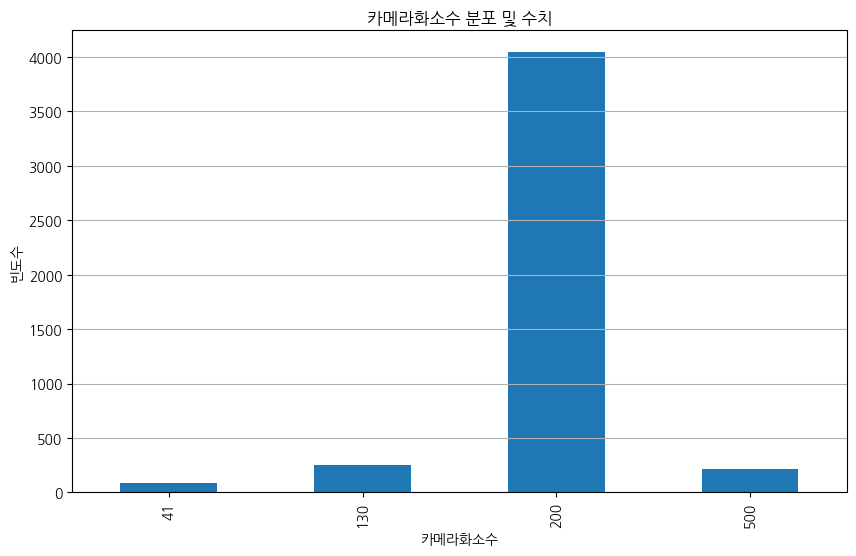

In [12]:
import matplotlib.pyplot as plt

# 카메라화소수별 빈도수 계산
pixel_counts = filtered_df_no_zero['카메라화소수'].value_counts().sort_index()

# 각 화소수별 CCTV 대수 출력
print("카메라화소수별 CCTV 대수:")
print(pixel_counts)

# 막대그래프 시각화
plt.figure(figsize=(10,6))
pixel_counts.plot(kind='bar')
plt.title('카메라화소수 분포 및 수치')
plt.xlabel('카메라화소수')
plt.ylabel('빈도수')
plt.grid(axis='y')
plt.show()


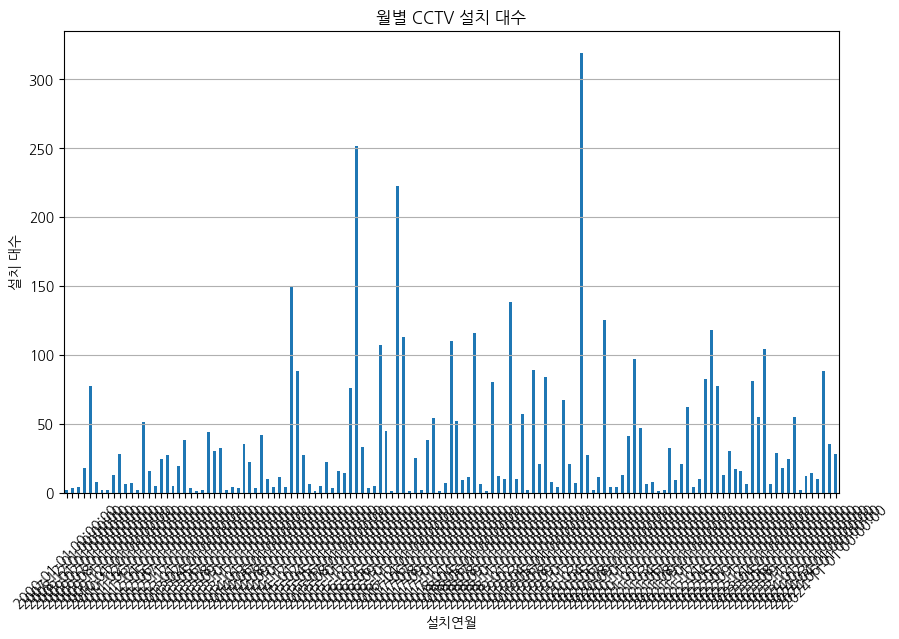

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# '설치연월'을 datetime으로 변환
filtered_df_no_zero['설치연월'] = pd.to_datetime(filtered_df_no_zero['설치연월'], format='%Y-%m')

# 월별 설치 대수 집계
install_counts = filtered_df_no_zero['설치연월'].value_counts().sort_index()

# 바 차트
plt.figure(figsize=(10,6))
install_counts.plot(kind='bar')
plt.title('월별 CCTV 설치 대수')
plt.xlabel('설치연월')
plt.ylabel('설치 대수')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()




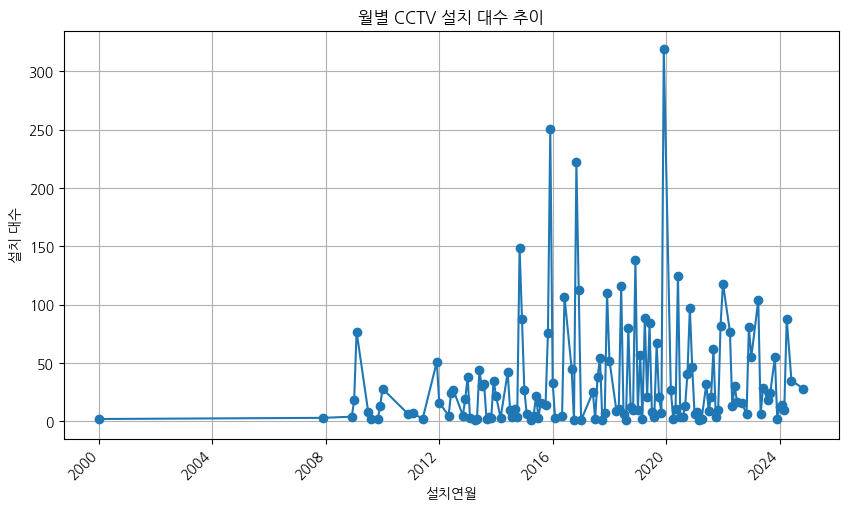

In [14]:
plt.figure(figsize=(10,6))
install_counts.plot(kind='line', marker='o')
plt.title('월별 CCTV 설치 대수 추이')
plt.xlabel('설치연월')
plt.ylabel('설치 대수')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

== CCTV 교체 우선순위 목록 ==
           설치연월  카메라화소수    설치경과월    우선순위점수
5267 2009-01-01      41  8611477  0.855010
5269 2009-01-01      41  8611477  0.855010
5010 2009-02-01      41  8566837  0.853643
5006 2009-02-01      41  8566837  0.853643
4862 2009-02-01      41  8566837  0.853643
5021 2009-02-01      41  8566837  0.853643
5016 2009-02-01      41  8566837  0.853643
5086 2009-02-01      41  8566837  0.853643
5109 2009-02-01      41  8566837  0.853643
5105 2009-02-01      41  8566837  0.853643
5059 2009-02-01      41  8566837  0.853643
5061 2009-02-01      41  8566837  0.853643
7224 2009-02-01      41  8566837  0.853643
5012 2009-02-01      41  8566837  0.853643
6917 2009-02-01      41  8566837  0.853643
6914 2009-02-01      41  8566837  0.853643
6910 2009-02-01      41  8566837  0.853643
6998 2009-02-01      41  8566837  0.853643
6908 2009-02-01      41  8566837  0.853643
7002 2009-02-01      41  8566837  0.853643


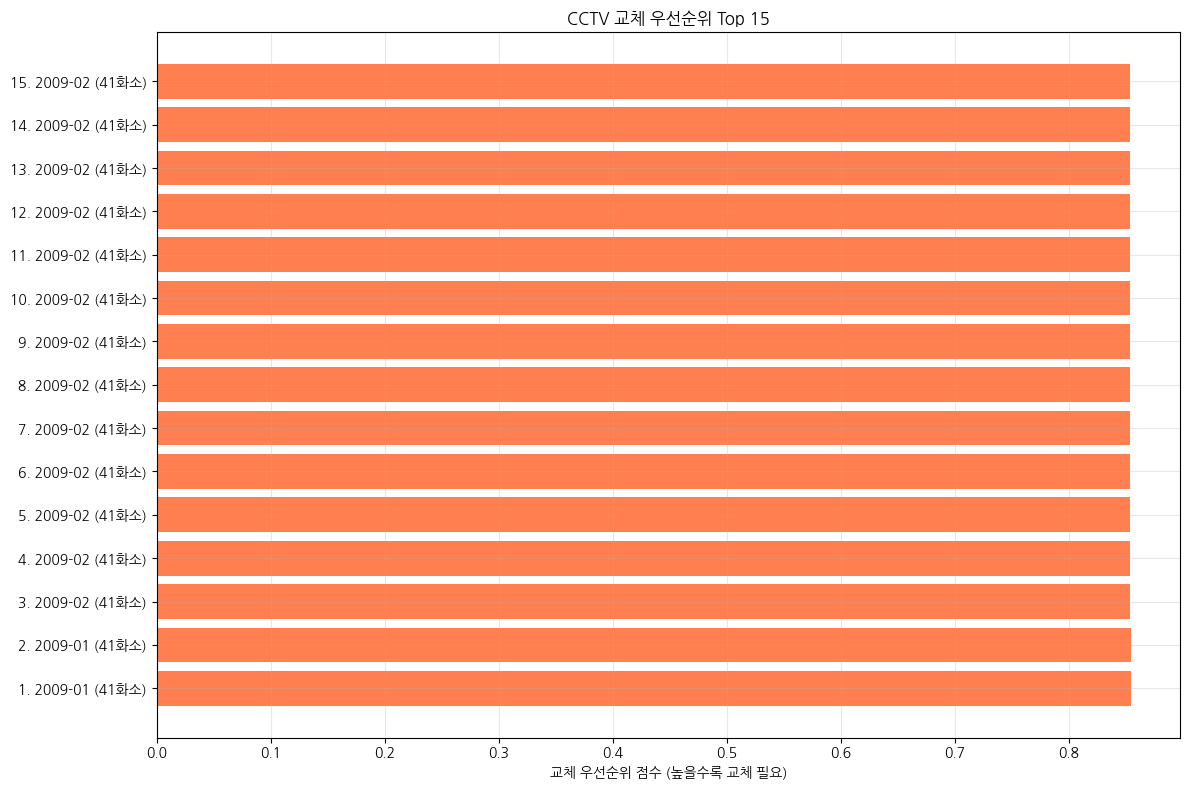

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 현재 날짜
current_date = pd.Timestamp.now()

# 설치연월을 datetime으로 변환
df = filtered_df_no_zero.copy()
df['설치연월'] = pd.to_datetime(df['설치연월'], format='%Y-%m')

# 설치경과월 계산 (일 단위 차이 / 30)
df['설치경과월'] = ((current_date - df['설치연월']).dt.days / 30).astype(int)


# 현재 날짜 설정
current_date = pd.Timestamp.now()

# 데이터프레임 사용 가정 (filtered_df_no_zero 데이터프레임을 사용한다고 가정)
# 1. 설치연월 datetime으로 변환
df = filtered_df_no_zero.copy()
df['설치연월'] = pd.to_datetime(df['설치연월'], format='%Y-%m')

# 2. 설치 경과 개월수 계산
df['설치경과월'] = ((current_date - df['설치연월']) / np.timedelta64(1, 'm')).astype(int)

# 3. 우선순위 점수 계산 (설치 경과 개월수가 클수록, 화소수가 낮을수록 높은 점수)
# 두 값을 정규화하여 가중치 적용
max_month = df['설치경과월'].max()
min_month = df['설치경과월'].min()
max_pixel = df['카메라화소수'].max()
min_pixel = df['카메라화소수'].min()

# 설치경과월 정규화 (오래될수록 높은 점수)
df['경과월_점수'] = (df['설치경과월'] - min_month) / (max_month - min_month) if (max_month != min_month) else 0

# 화소수 정규화 (낮을수록 높은 점수 = 역정규화)
df['화소수_점수'] = (max_pixel - df['카메라화소수']) / (max_pixel - min_pixel) if (max_pixel != min_pixel) else 0

# 최종 우선순위 점수 계산 (가중치: 설치경과월 60%, 화소수 40%)
df['우선순위점수'] = 0.4 * df['경과월_점수'] + 0.6 * df['화소수_점수']

# 우선순위 정렬
priority_cctv = df.sort_values('우선순위점수', ascending=False)

# 결과 출력
print("== CCTV 교체 우선순위 목록 ==")
top_n = 20  # 상위 20개
result = priority_cctv.head(top_n)[['설치연월', '카메라화소수', '설치경과월', '우선순위점수']]
print(result)

# 시각화
plt.figure(figsize=(12, 8))
top_n = 15  # 상위 15개만 시각화

# 막대 그래프로 우선순위 시각화
plt.barh(range(top_n), priority_cctv.head(top_n)['우선순위점수'], color='coral')
plt.yticks(range(top_n),
          [f"{i+1}. {y.strftime('%Y-%m')} ({p}화소)"
           for i, (y, p) in enumerate(zip(
               priority_cctv.head(top_n)['설치연월'],
               priority_cctv.head(top_n)['카메라화소수']
           ))]
)
plt.title('CCTV 교체 우선순위 Top 15')
plt.xlabel('교체 우선순위 점수 (높을수록 교체 필요)')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


== CCTV 교체 우선순위 목록 ==
           설치연월  카메라화소수     설치경과월    우선순위점수
36   2000-01-01     200  13346197  0.861438
37   2000-01-01     200  13346197  0.861438
5267 2009-01-01      41   8611477  0.782516
5269 2009-01-01      41   8611477  0.782516
5012 2009-02-01      41   8566837  0.780465
7224 2009-02-01      41   8566837  0.780465
5090 2009-02-01      41   8566837  0.780465
7073 2009-02-01      41   8566837  0.780465
5113 2009-02-01      41   8566837  0.780465
5098 2009-02-01      41   8566837  0.780465
5102 2009-02-01      41   8566837  0.780465
5105 2009-02-01      41   8566837  0.780465
5021 2009-02-01      41   8566837  0.780465
7220 2009-02-01      41   8566837  0.780465
7214 2009-02-01      41   8566837  0.780465
5061 2009-02-01      41   8566837  0.780465
5016 2009-02-01      41   8566837  0.780465
5006 2009-02-01      41   8566837  0.780465
5010 2009-02-01      41   8566837  0.780465
4862 2009-02-01      41   8566837  0.780465


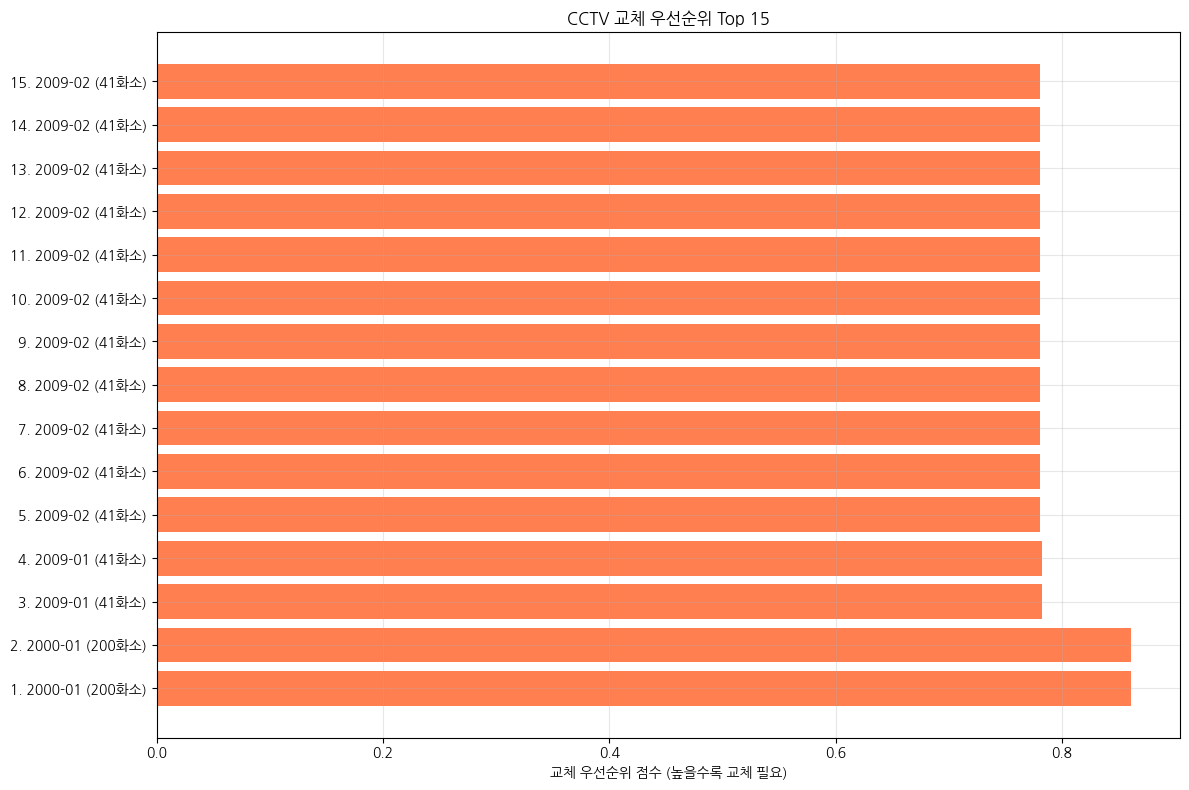

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 현재 날짜
current_date = pd.Timestamp.now()

# 설치연월을 datetime으로 변환
df = filtered_df_no_zero.copy()
df['설치연월'] = pd.to_datetime(df['설치연월'], format='%Y-%m')

# 설치경과월 계산 (일 단위 차이 / 30)
df['설치경과월'] = ((current_date - df['설치연월']).dt.days / 30).astype(int)


# 현재 날짜 설정
current_date = pd.Timestamp.now()

# 데이터프레임 사용 가정 (filtered_df_no_zero 데이터프레임을 사용한다고 가정)
# 1. 설치연월 datetime으로 변환
df = filtered_df_no_zero.copy()
df['설치연월'] = pd.to_datetime(df['설치연월'], format='%Y-%m')

# 2. 설치 경과 개월수 계산
df['설치경과월'] = ((current_date - df['설치연월']) / np.timedelta64(1, 'm')).astype(int)

# 3. 우선순위 점수 계산 (설치 경과 개월수가 클수록, 화소수가 낮을수록 높은 점수)
# 두 값을 정규화하여 가중치 적용
max_month = df['설치경과월'].max()
min_month = df['설치경과월'].min()
max_pixel = df['카메라화소수'].max()
min_pixel = df['카메라화소수'].min()

# 설치경과월 정규화 (오래될수록 높은 점수)
df['경과월_점수'] = (df['설치경과월'] - min_month) / (max_month - min_month) if (max_month != min_month) else 0

# 화소수 정규화 (낮을수록 높은 점수 = 역정규화)
df['화소수_점수'] = (max_pixel - df['카메라화소수']) / (max_pixel - min_pixel) if (max_pixel != min_pixel) else 0

# 최종 우선순위 점수 계산 (가중치: 설치경과월 60%, 화소수 40%)
df['우선순위점수'] = 0.6 * df['경과월_점수'] + 0.4 * df['화소수_점수']

# 우선순위 정렬
priority_cctv = df.sort_values('우선순위점수', ascending=False)

# 결과 출력
print("== CCTV 교체 우선순위 목록 ==")
top_n = 20  # 상위 20개
result = priority_cctv.head(top_n)[['설치연월', '카메라화소수', '설치경과월', '우선순위점수']]
print(result)

# 시각화
plt.figure(figsize=(12, 8))
top_n = 15  # 상위 15개만 시각화

# 막대 그래프로 우선순위 시각화
plt.barh(range(top_n), priority_cctv.head(top_n)['우선순위점수'], color='coral')
plt.yticks(range(top_n),
          [f"{i+1}. {y.strftime('%Y-%m')} ({p}화소)"
           for i, (y, p) in enumerate(zip(
               priority_cctv.head(top_n)['설치연월'],
               priority_cctv.head(top_n)['카메라화소수']
           ))]
)
plt.title('CCTV 교체 우선순위 Top 15')
plt.xlabel('교체 우선순위 점수 (높을수록 교체 필요)')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


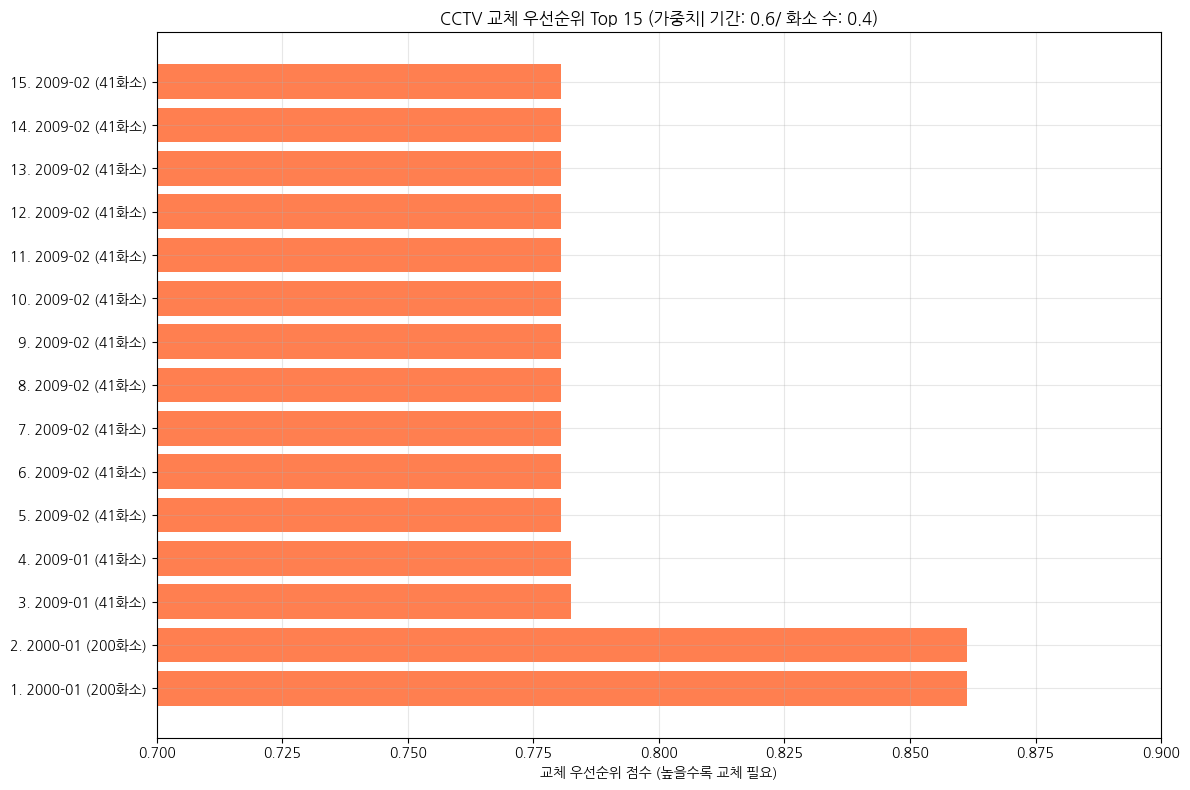

In [17]:
plt.figure(figsize=(12, 8))
plt.barh(range(15), priority_cctv.head(15)['우선순위점수'], color='coral')
plt.yticks(range(15),
          [f"{i+1}. {y.strftime('%Y-%m')} ({p}화소)"
           for i, (y, p) in enumerate(zip(
               priority_cctv.head(15)['설치연월'],
               priority_cctv.head(15)['카메라화소수']
           ))]
)
plt.title('CCTV 교체 우선순위 Top 15 (가중치| 기간: 0.6/ 화소 수: 0.4)')
plt.xlabel('교체 우선순위 점수 (높을수록 교체 필요)')
plt.xlim(0.7, 0.9)  # x축 범위 확대
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


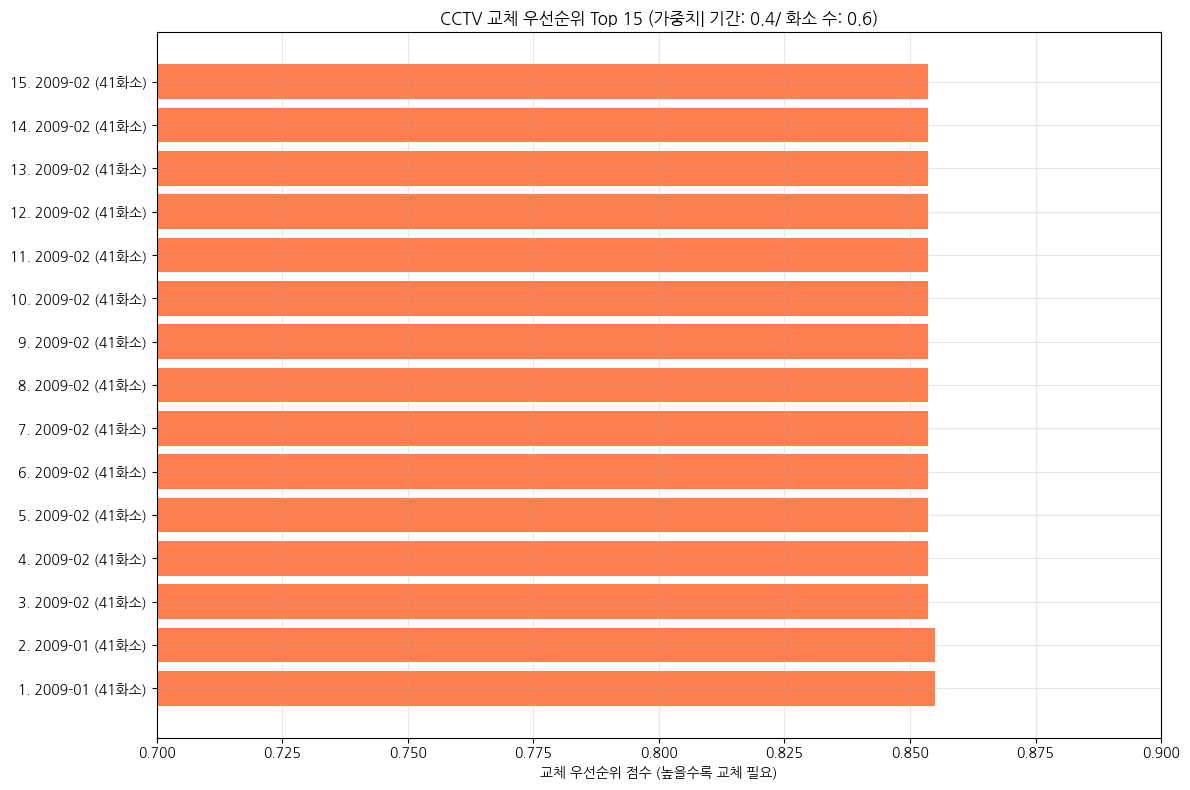

In [19]:
plt.figure(figsize=(12, 8))
plt.barh(range(15), priority_cctv.head(15)['우선순위점수'], color='coral')
plt.yticks(range(15),
          [f"{i+1}. {y.strftime('%Y-%m')} ({p}화소)"
           for i, (y, p) in enumerate(zip(
               priority_cctv.head(15)['설치연월'],
               priority_cctv.head(15)['카메라화소수']
           ))]
)
plt.title('CCTV 교체 우선순위 Top 15 (가중치| 기간: 0.4/ 화소 수: 0.6)')
plt.xlabel('교체 우선순위 점수 (높을수록 교체 필요)')
plt.xlim(0.7, 0.9)  # x축 범위 확대
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()
